# Análisis y Predicción del Precio de Automóviles mediante la Metodología CRISP-DM (UCI Automobile Dataset)

**Autor:** Efren Cherres

**Fecha:** 9/10/2025

**Dataset:** Automobile.

**Objetivo:** Construir un modelo que prediga el precio (price) de automóviles a partir de las demás variables del dataset Automobile (UCI).

# CRISP-DM

## Business Understanding
**Meta:** Desarrollar un modelo predictivo capaz de estimar con precisión el precio de los automóviles, proporcionando una herramienta de valor para la valoración de vehículos, el análisis del mercado automotriz y la optimización de sistemas de recomendación basados en características técnicas y de desempeño.

El proceso incluye:

*Análisis univariante:* exploración individual de las variables para detectar patrones, valores atípicos y distribución de datos.

*Análisis multivariante:* identificación de correlaciones y relaciones entre variables predictoras y el precio.

*Modelado predictivo:* construcción de modelos de regresión lineal y no lineal, con optimización de hiperparámetros para maximizar el rendimiento mediante métricas como R², RMSE y MAE.

El resultado final permitirá comparar enfoques y determinar el modelo más preciso y robusto para la predicción del precio automotriz.

# Sección 1 – Carga de librerías
Objetivo: importar las librerías necesarias para análisis, visualización y modelado.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from scipy.stats import zscore
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns
import xgboost as xgb



# Sección 2 – Carga de la base de datos
Objetivo: importar el dataset y hacer una primera inspección.

Acciones:

importar la data

Verificar dimensiones y primeras filas.

Revisar tipos de variables y valores nulos.

In [ ]:
# Cargar dataset (UCI)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
col_names = [
    "symboling","normalized-losses","make","fuel-type","aspiration","num-of-doors",
    "body-style","drive-wheels","engine-location","wheel-base","length","width","height",
    "curb-weight","engine-type","num-of-cylinders","engine-size","fuel-system","bore",
    "stroke","compression-ratio","horsepower","peak-rpm","city-mpg","highway-mpg","price"
]
df_automobile = pd.read_csv(url, names=col_names, na_values='?')


# Data Understanding

In [ ]:
# Inspección rápida de la data

print("Dimensiones del dataset:", df_automobile.shape)
print("\nPrimeras filas:")
display(df_automobile.head())




Dimensiones del dataset: (205, 26)

Primeras filas:


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [ ]:
print("\nTipos de datos:")
print(df_automobile.dtypes)


Tipos de datos:
symboling              int64
normalized-losses    float64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object


El conjunto de datos contiene 205 registros y 26 variables, lo que indica una base de información de tamaño moderado, ideal para análisis exploratorio y modelado predictivo. Cada fila representa un automóvil único, y las columnas describen sus características técnicas, estructurales y de desempeño, junto con su precio final (variable objetivo).

Entre las variables observadas se incluyen:

Datos técnicos: engine-size, horsepower, compression-ratio, peak-rpm, city-mpg, highway-mpg.

Atributos de diseño: body-style, num-of-doors, drive-wheels, engine-location.

Datos categóricos clave: make (marca), fuel-type, aspiration.

Variable objetivo: price, que será el foco del análisis y modelado predictivo.

Se identifican valores faltantes en columnas como normalized-losses, lo que exige un tratamiento previo. La variable price es continua, confirmando un problema de regresión. El dataset combina variables numéricas y categóricas, por lo que se requerirá preprocesamiento mixto. La variedad de fabricantes permitirá analizar tendencias de precios según marca y configuración técnica.

In [ ]:
# Calcular valores nulos y su porcentaje
valores_nulos = df_automobile.isnull().sum()
porcentaje_nulos = (df_automobile.isnull().mean() * 100).round(2)

tabla_nulos = pd.DataFrame({
    'Valores Nulos': valores_nulos,
    'Porcentaje (%)': porcentaje_nulos
})

print("\nResumen de valores nulos por columna:")
print(tabla_nulos)


Resumen de valores nulos por columna:
                   Valores Nulos  Porcentaje (%)
symboling                      0            0.00
normalized-losses             41           20.00
make                           0            0.00
fuel-type                      0            0.00
aspiration                     0            0.00
num-of-doors                   2            0.98
body-style                     0            0.00
drive-wheels                   0            0.00
engine-location                0            0.00
wheel-base                     0            0.00
length                         0            0.00
width                          0            0.00
height                         0            0.00
curb-weight                    0            0.00
engine-type                    0            0.00
num-of-cylinders               0            0.00
engine-size                    0            0.00
fuel-system                    0            0.00
bore                          

La mayoría de las columnas están completas, pero **"normalized-losses"** necesita atención especial por su alta proporción de nulos. Las demás columnas con pocos nulos nos tocaria hacerle alguna imputracion o eliminar para que el dataset está limpio y adecuado para análisis.

In [ ]:
df_automobile.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,164.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


Al analizar las características de los autos, se observa una gran diversidad en tamaño, potencia y precio. La mayoría de vehículos son medianos y ligeros, con motores de tamaño y potencia moderados, aunque existen algunos autos grandes y de alto rendimiento que elevan la media y crean valores extremos. Las pérdidas normalizadas (normalized-losses) y el precio muestran sesgo positivo, lo que sugiere que unos pocos autos con altos costos afectan la media. Esto resalta la importancia de imputar valores nulos con un metodo y considerar escalado o normalización para modelado predictivo, asegurando que los outliers no distorsionen los resultados y que la tendencia central represente adecuadamente la mayoría de autos.

# Data Preparation (decisiones principales)

Text(0.5, 1.0, 'Distribución Original con Nulos')

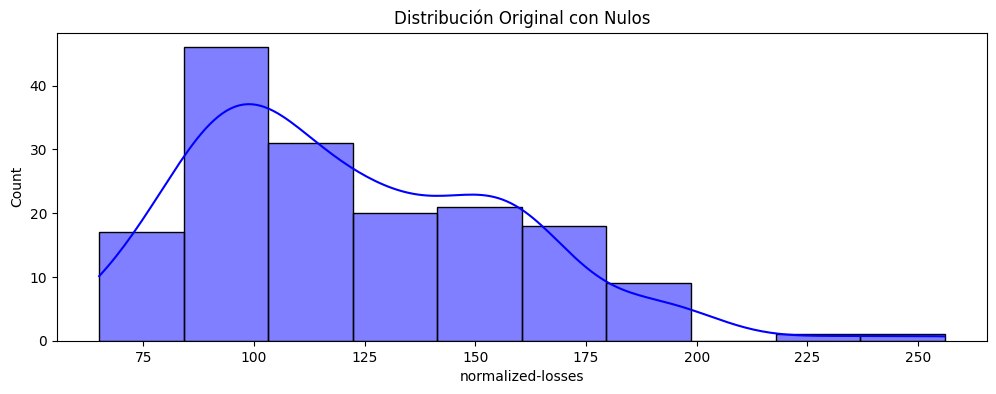

In [ ]:
# Verificamos con un histograma que valor deberiamos imputar al valor nulo con mayor porcentaje
plt.figure(figsize=(12,4))
sns.histplot(df_automobile["normalized-losses"], kde=True, color="blue")
plt.title("Distribución Original con Nulos")

In [ ]:
# Revisamos los valores de la Mediana, Media y Moda de normalized-losses
mediana_hp = df_automobile['normalized-losses'].median()
media_hp = df_automobile['normalized-losses'].mean()
moda_hp = df_automobile['normalized-losses'].mode()[0]
print("Mediana de normalized-losses:", mediana_hp)
print("Media de normalized-losses:", media_hp)
print("Moda de normalized-losses:", moda_hp)

Mediana de normalized-losses: 115.0
Media de normalized-losses: 122.0
Moda de normalized-losses: 161.0


Tendencia central:

Mediana: 115.0 → indica que la mitad de los autos tienen pérdidas por debajo de este valor, siendo un valor representativo para la mayoría de vehículos.

Media: 122.0 → ligeramente mayor que la mediana, lo que confirma el sesgo positivo (los valores altos influyen en la media).

Moda: 161.0 → valor que ocurre con mayor frecuencia, pero que está desplazado hacia valores más altos debido a algunos casos atípicos.

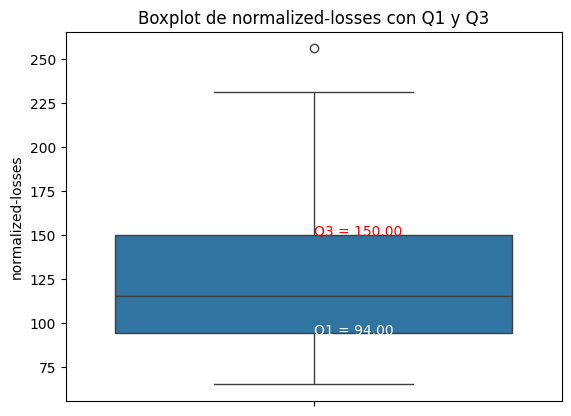

In [ ]:
# Revisamos con boxplot

# Calcular Q1 y Q3
Q1 = df_automobile['normalized-losses'].quantile(0.25)
Q3 = df_automobile['normalized-losses'].quantile(0.75)

# Crear el boxplot
sns.boxplot(y=df_automobile['normalized-losses'])
plt.title('Boxplot de normalized-losses con Q1 y Q3')
plt.ylabel('normalized-losses')

# Añadir anotaciones de Q1 y Q3
plt.text(0, Q1, f'Q1 = {Q1:.2f}', horizontalalignment='left', color='white')
plt.text(0, Q3, f'Q3 = {Q3:.2f}', horizontalalignment='left', color='red')

plt.show()

Dado que la distribución está sesgada y existen valores atípicos, imputar con la mediana (115.0) sería lo más recomendable que usar la media, ya que es robusta frente a valores extremos.

No podemos usar la moda (161.0) para imputación, porque no representa la tendencia central general de la mayoría de los autos.

en funcion de lo obervado entonces procedemos a reemplazar los nulos usando la mediana. De esta forma, los outliers extremos no afectan la imputación y obtengo un valor más representativo de la tendencia central real de los datos.

In [ ]:
# imputamos a la variable normalized-losses el valor de la mediana
df_automobile['normalized-losses'].fillna(df_automobile['normalized-losses'].median())

print(df_automobile.isnull().sum())

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64


In [ ]:
# Eliminamos nulos menores
df_automobile = df_automobile.dropna()
print(df_automobile.isnull().sum())

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


## Tratamiento de las escalas con Estandarizacion (Z-score)

In [ ]:
# Seleccionamos solo las columnas numéricas
numericas = df_automobile.select_dtypes(include=['float64', 'int64']).columns

# Aplicamos Z-score
df_automobile_normalizado = df_automobile.copy()
df_automobile_normalizado[numericas] = df_automobile[numericas].apply(zscore)

# Revisamos los primeros registros
print(df_automobile_normalizado.head())

    symboling  normalized-losses  make fuel-type aspiration num-of-doors  \
3    1.062912           1.206222  audi       gas        std         four   
4    1.062912           1.206222  audi       gas        std         four   
6    0.222101           1.037394  audi       gas        std         four   
8    0.222101           1.037394  audi       gas      turbo         four   
10   1.062912           1.994089   bmw       gas        std          two   

   body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
3       sedan          fwd           front    0.298157  ...    -0.336785   
4       sedan          4wd           front    0.220504  ...     0.552401   
6       sedan          fwd           front    1.462948  ...     0.552401   
8       sedan          fwd           front    1.462948  ...     0.387737   
10      sedan          rwd           front    0.569942  ...    -0.369717   

    fuel-system      bore    stroke compression-ratio horsepower  peak-rpm  \
3       

## Matriz de Correlacion

In [ ]:
# Seleccionamos solo columnas numéricas
numericas = df_automobile_normalizado.select_dtypes(include=['float64', 'int64'])

# Matriz de correlación
matriz_corr = numericas.corr(method='pearson')
matriz_corr

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
symboling,1.000000,0.518344,-0.520591,-0.336257,-0.219186,-0.475185,-0.251880,-0.109453,-0.256469,-0.021285,-0.138316,-0.003949,0.199106,0.089550,0.149830,-0.162794
normalized-losses,0.518344,1.000000,-0.060086,0.035541,0.109726,-0.413702,0.125858,0.207820,-0.031558,0.063330,-0.127259,0.290511,0.237697,-0.235523,-0.188564,0.202761
wheel-base,-0.520591,-0.060086,1.000000,0.871534,0.814991,0.555767,0.810181,0.649206,0.578159,0.167449,0.291431,0.516948,-0.289234,-0.580657,-0.611750,0.734419
length,-0.336257,0.035541,0.871534,1.000000,0.838338,0.499251,0.871291,0.725953,0.646318,0.121073,0.184814,0.672063,-0.234074,-0.724544,-0.724599,0.760952
width,-0.219186,0.109726,0.814991,0.838338,1.000000,0.292706,0.870595,0.779253,0.572554,0.196619,0.258752,0.681872,-0.232216,-0.666684,-0.693339,0.843371
height,-0.475185,-0.413702,0.555767,0.499251,0.292706,1.000000,0.367052,0.111083,0.254836,-0.091313,0.233308,0.034317,-0.245864,-0.199737,-0.226136,0.244836
curb-weight,-0.251880,0.125858,0.810181,0.871291,0.870595,0.367052,1.000000,0.888626,0.645792,0.173844,0.224724,0.790095,-0.259988,-0.762155,-0.789338,0.893639
engine-size,-0.109453,0.207820,0.649206,0.725953,0.779253,0.111083,0.888626,1.000000,0.595737,0.299683,0.141097,0.812073,-0.284686,-0.699139,-0.714095,0.841496
bore,-0.256469,-0.031558,0.578159,0.646318,0.572554,0.254836,0.645792,0.595737,1.000000,-0.102581,0.015119,0.560239,-0.312269,-0.590440,-0.590850,0.533890
stroke,-0.021285,0.063330,0.167449,0.121073,0.196619,-0.091313,0.173844,0.299683,-0.102581,1.000000,0.243587,0.148804,-0.011312,-0.020055,-0.012934,0.160664


In [ ]:
matriz_corr["price"].sort_values(ascending=False)

,price
price,1.000000
curb-weight,0.893639
width,0.843371
engine-size,0.841496
length,0.760952
horsepower,0.759874
wheel-base,0.734419
bore,0.533890
height,0.244836
compression-ratio,0.209361


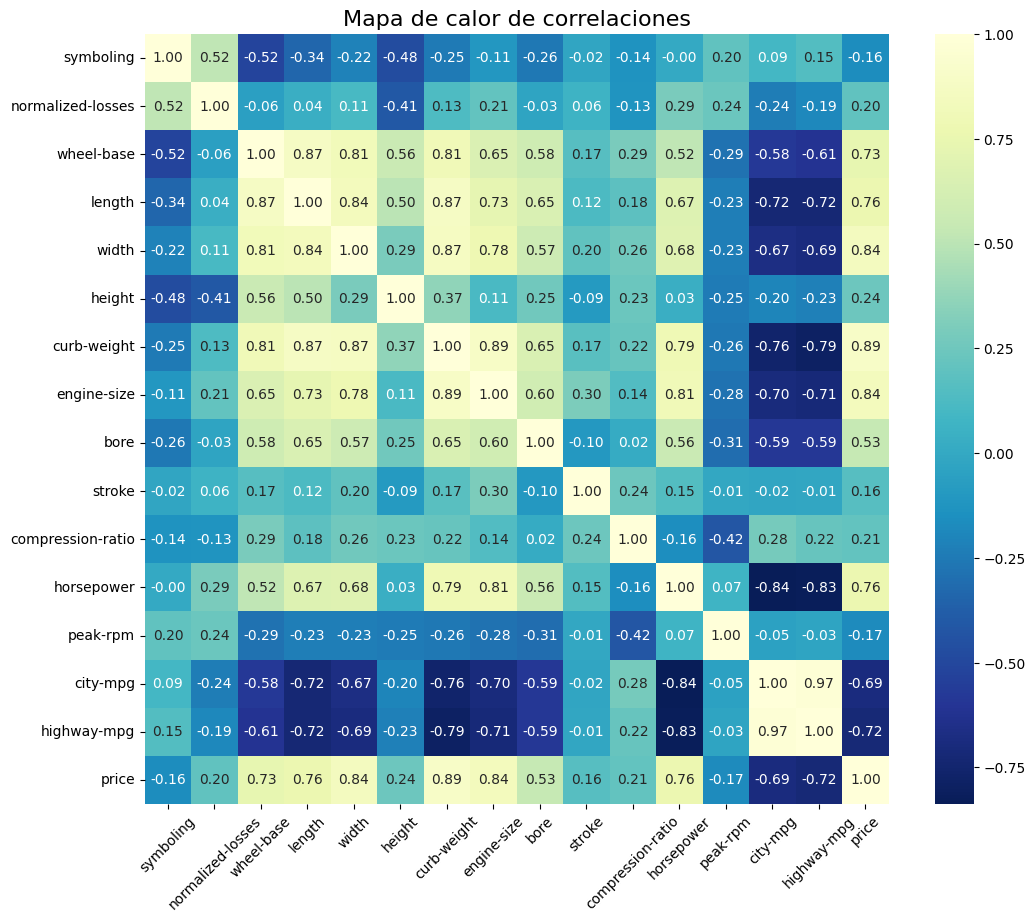

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",             # Formato con 2 decimales
    cmap='YlGnBu_r',
    annot_kws={"size":10}
)
plt.xticks(rotation=45)     # Rota etiquetas del eje x
plt.yticks(rotation=0)      # Etiquetas del eje y horizontales
plt.title("Mapa de calor de correlaciones", fontsize=16)
plt.show()

## Separación de datos en entrenamiento y prueba (70% / 30%).

In [ ]:
# Definimos variables predictoras X y variable objetivo y
X = df_automobile.drop(['price'], axis=1)
y = df_automobile['price']               # variable a predecir

# Separación en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Verificamos tamaños
print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)
print("Tamaño y_train:", y_train.shape)
print("Tamaño y_test:", y_test.shape)

Tamaño X_train: (111, 25)
Tamaño X_test: (48, 25)
Tamaño y_train: (111,)
Tamaño y_test: (48,)


# Modeling

## Modelo de Regresión Lineal Simple (Análisis Univariante)

Variable: engine-size
  Coeficiente: 162.38
  Intercepto: -7914.13

Variable: width
  Coeficiente: 2544.92
  Intercepto: -155520.41

Variable: curb-weight
  Coeficiente: 10.90
  Intercepto: -15378.23



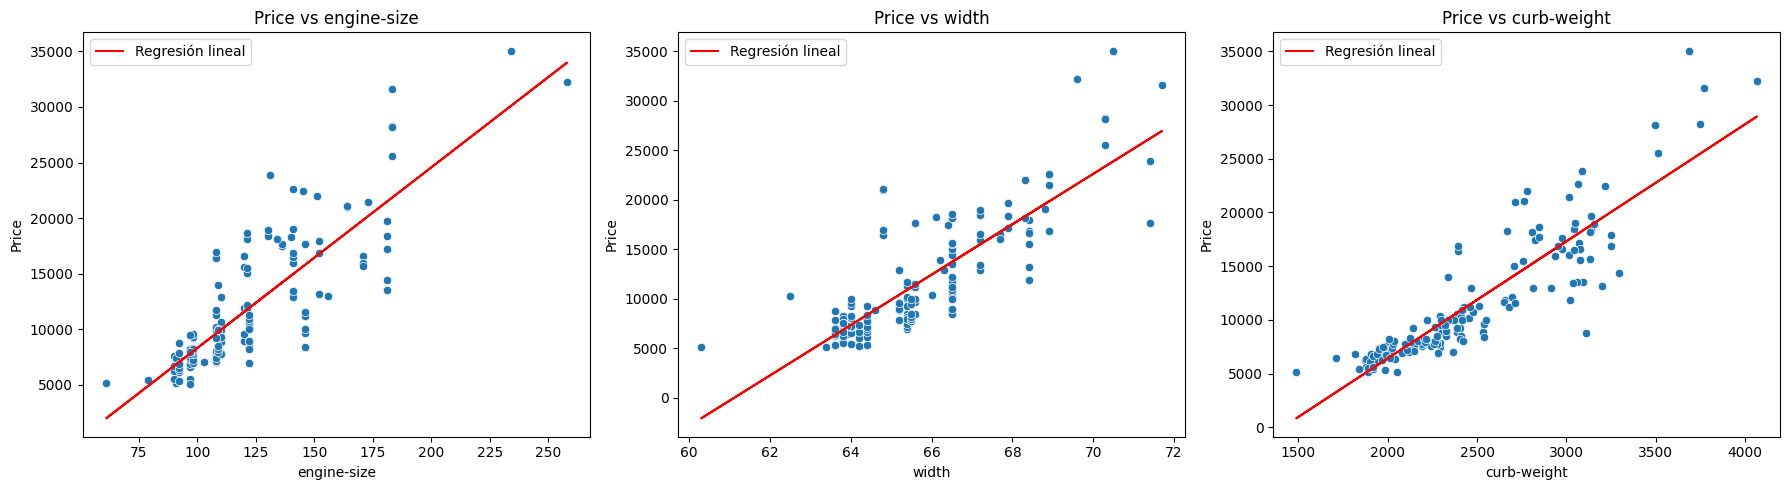

In [ ]:
# Variables univariantes a analizar
variables = ['engine-size', 'width', 'curb-weight']

# Crear figura para los gráficos
plt.figure(figsize=(18, 5))

for i, var in enumerate(variables):
    # Selección de variable y target
    X = df_automobile[[var]]
    y = df_automobile['price']

    # Modelo de regresión lineal univariante
    model_uni = LinearRegression()
    model_uni.fit(X, y)
    y_pred = model_uni.predict(X)

    # Mostrar coeficiente e intercepto
    print(f"Variable: {var}")
    print(f"  Coeficiente: {model_uni.coef_[0]:.2f}")
    print(f"  Intercepto: {model_uni.intercept_:.2f}\n")

    # Gráfico
    plt.subplot(1, 3, i+1)
    sns.scatterplot(x=X[var], y=y)
    plt.plot(X[var], y_pred, color='red', label='Regresión lineal')
    plt.xlabel(var)
    plt.ylabel("Price")
    plt.title(f"Price vs {var}")
    plt.legend()

plt.tight_layout()
plt.show()

# Conclusión del Análisis Univariante

Variable        | Coeficiente | Intercepto  | Interpretación
----------------|------------|------------|---------------------------------------------------------------
engine-size     | 162.38     | -7914.13   | Por cada unidad extra en el motor, el precio aumenta ~\$162.
width           | 2544.92    | -155520.41 | A mayor ancho del vehículo, el precio incrementa ~\$2,544.
curb-weight     | 10.90      | -15378.23  | A mayor peso del vehículo, el precio aumenta ~\$11.

**Insight general:**  
Engine-size y width tienen un impacto considerable sobre el precio, mientras que curb-weight contribuye de manera más modesta. Un modelo multivariante permitiría capturar mejor las interacciones y mejorar la predicción.

## Modelo KNN Regressor (Análisis Multivariante)

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
# Separar variables predictoras (X) y objetivo (y)
X = df_automobile.drop('price', axis=1)
y = df_automobile['price']

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identificar columnas categóricas y numéricas
cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(exclude=['object']).columns

# Crear el preprocesador (OneHot + Escalado)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

# Pipeline con modelo KNN
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor())
])

# Búsqueda de hiperparámetros (GridSearchCV)
param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]  # 1 = Manhattan, 2 = Euclidiana
}

grid_search = GridSearchCV(knn_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Mejor modelo
best_knn = grid_search.best_estimator_

print("✅ Mejor configuración encontrada:")
print(grid_search.best_params_)

# Evaluación en datos de prueba
y_pred = best_knn.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n📊 Resultados del modelo KNN Regressor:")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

✅ Mejor configuración encontrada:
{'model__n_neighbors': 5, 'model__p': 1, 'model__weights': 'distance'}

📊 Resultados del modelo KNN Regressor:
R²: 0.8077
MAE: 1402.96
RMSE: 1849.91


In [ ]:
# Creamos un DataFrame con precios reales, predichos y margen de error
tabla_resultados = pd.DataFrame({
    'Precio Real': y_test,
    'Precio Predicho': y_pred,
    'Error Absoluto': np.abs(y_test - y_pred)  # diferencia absoluta
})

# Mostrar las primeras 10 filas
tabla_resultados.head(10)

,Precio Real,Precio Predicho,Error Absoluto
108,13200.0,17465.240216,4265.240216
201,19045.0,19299.473885,254.473885
169,9989.0,11705.545717,1716.545717
85,6989.0,9220.143581,2231.143581
135,15510.0,12119.870948,3390.129052
40,10295.0,8695.506416,1599.493584
190,9980.0,8418.011046,1561.988954
78,6669.0,6129.388726,539.611274
139,7053.0,6697.939737,355.060263
183,7975.0,9085.574482,1110.574482


El modelo KNN predice correctamente la tendencia general de los precios de los autos, con errores moderados en la mayoría de los casos. Los errores absolutos son razonables, aunque tiende a suavizar los extremos, sobreestimando algunos autos baratos y subestimando algunos caros. En general, las predicciones son confiables para análisis y decisiones.

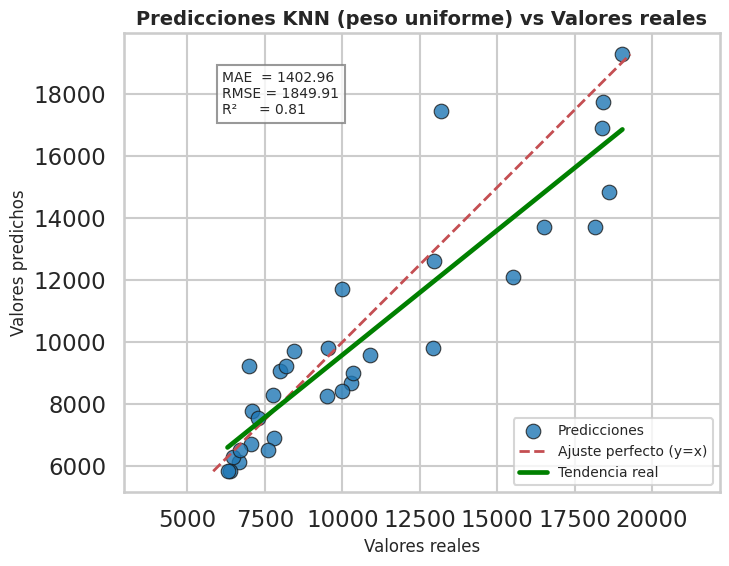

In [ ]:

# Ajustar rango de ejes
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(8, 6))

# Puntos de dispersión
sns.scatterplot(x=y_test, y=y_pred, s=110, color="#1f77b4", edgecolor="k", alpha=0.8, label="Predicciones")

# Línea perfecta (y=x)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Ajuste perfecto (y=x)")

# Línea de regresión ajustada
sns.regplot(x=y_test, y=y_pred, scatter=False, color="green", ci=None, label="Tendencia real")

# Etiquetas
plt.xlabel("Valores reales", fontsize=12)
plt.ylabel("Valores predichos", fontsize=12)
plt.title("Predicciones KNN (peso uniforme) vs Valores reales", fontsize=14, fontweight="bold")

# Métricas con fuente más pequeña
plt.text(min_val*1.05, max_val*0.9,
         f"MAE  = {mae:.2f}\nRMSE = {rmse:.2f}\nR²     = {r2:.2f}",
         fontsize=10, bbox=dict(facecolor="white", edgecolor="gray", alpha=0.8))

plt.legend(fontsize=10)
plt.axis("equal")  # misma escala en ambos ejes
plt.tight_layout()
plt.show()

El modelo tuvo un buen desempeño (R² > 0.8) considerando la variabilidad de los precios de autos. La imputación y el escalado funcionaron bien, permitiéndome usar KNN con variables numéricas y categóricas. Los errores promedio (MAE y RMSE) muestran que las predicciones son bastante precisas, aunque los autos muy caros o muy baratos pueden desviarse un poco. Elegir Manhattan y pesos por distancia me permitió dar más importancia a los vecinos más similares, mejorando la precisión.

Insight final:
El modelo KNN multivariante es efectivo para predecir precios basándose en características como tamaño del motor, potencia, peso y tipo de combustible, capturando relaciones no lineales que la regresión lineal simple no detecto.

# Modelo RandomForest

In [ ]:
# Aplicamos modelo Randomforest

# Separamos las variables predictoras (X) y objetivo (y)
X = df_automobile.drop('price', axis=1)
y = df_automobile['price']

# Convertimos variables categóricas (object o string) a dummies
X = pd.get_dummies(X, drop_first=True)

print("Variables categóricas convertidas. Nueva forma de X:", X.shape)

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Crear el modelo base ---
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# ---  Búsqueda de hiperparámetros ---
param_grid = {
    'n_estimators': [100, 200, 300], # Número de árboles en el bosque.
    'max_depth': [10, 20, 30], # Profundidad máxima de cada árbol.
    'min_samples_split': [2, 5, 10], # Número mínimo de muestras requeridas para dividir un nodo interno.
    'min_samples_leaf': [1, 2, 3] # Número mínimo de muestras que debe tener una hoja después del split.
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='r2'
)

grid.fit(X_train, y_train)

# Mejor modelo encontrado
best_rf = grid.best_estimator_
print(" Mejores parámetros encontrados:", grid.best_params_)

# --- Evaluación del modelo ---
y_pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Resultados del modelo RandomForestRegressor:")
print(f"MAE  (Error Absoluto Medio): {mae:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")
print(f"R²   (Coeficiente de Determinación): {r2:.3f}")



Variables categóricas convertidas. Nueva forma de X: (159, 54)
 Mejores parámetros encontrados: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Resultados del modelo RandomForestRegressor:
MAE  (Error Absoluto Medio): 1354.34
RMSE (Raíz del Error Cuadrático Medio): 1879.18
R²   (Coeficiente de Determinación): 0.870


Insight del modelo RandomForest Regressor

El modelo RandomForest Regressor logró un R² de 0.87, demostrando una alta capacidad para predecir los precios de los vehículos a partir de sus características técnicas.
Esto significa que el 87% de la variación en el precio puede explicarse por las variables del modelo, lo cual refleja un nivel de precisión muy satisfactorio.

El error absoluto medio (MAE) de aproximadamente $1,354 indica que, en promedio, las predicciones se desvían poco del valor real del vehículo, lo que hace al modelo confiable para estimaciones prácticas.

Entre las variables más influyentes destacan el peso del vehículo, el ancho y el tamaño del motor, factores que están directamente relacionados con la potencia, el rendimiento y el segmento del automóvil, lo cual es coherente con la lógica del mercado automotriz.

En conjunto, el modelo ofrece una base sólida para estimar precios y detectar vehículos con valores atípicos, aportando un valor estratégico para decisiones de compra, venta o posicionamiento de productos en el mercado.

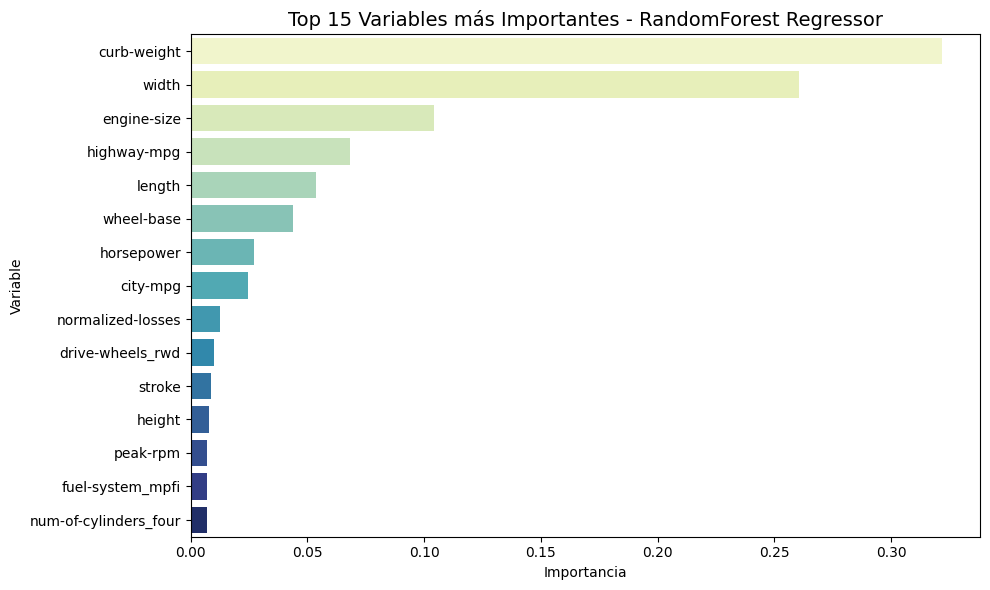

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Creamos DataFrame ordenado con las importancias
importance_df = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': best_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Mostrar las 15 más importantes
top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x='Importancia',
    y='Variable',
    palette='YlGnBu'
)
plt.title(f'Top {top_n} Variables más Importantes - RandomForest Regressor', fontsize=14)
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

*Insight del gráfico*

El análisis muestra que el precio de los vehículos está principalmente influenciado por características físicas y de rendimiento:

**curb-weight (peso del vehículo)** y **width (ancho)** son las variables más determinantes, representando juntas más del 50% de la importancia total del modelo. Esto indica que vehículos más pesados y anchos tienden a ser más costosos, probablemente por mayor tamaño, seguridad y segmentación premium.

**engine-size (tamaño del motor)** y **highway-mpg (eficiencia en carretera)** también tienen relevancia significativa, reflejando que la potencia y eficiencia energética afectan directamente la valoración del auto en el mercado.

Variables como **length, wheel-base y horsepower** tienen influencia moderada, mientras que factores más específicos o de menor impacto como **num-of-cylinders_four, fuel-system_mpfi o peak-rpm** contribuyen marginalmente a la predicción.

In [ ]:
# Separamos las variables predictoras (X) y objetivo (y)
X = df_automobile.drop('price', axis=1)
y = df_automobile['price']

# Convertimos variables categóricas (object o string) a dummies
X = pd.get_dummies(X, drop_first=True)

print("Variables categóricas convertidas. Nueva forma de X:", X.shape)

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Crear el modelo base ---
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Definir hiperparámetros para búsqueda
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# Búsqueda de hiperparámetros
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           cv=5, scoring='r2', verbose=1, n_jobs=-1)

grid_search.fit(X_train, y_train)

# Mejor modelo
best_xgb = grid_search.best_estimator_

# Predicciones
y_pred = best_xgb.predict(X_test)

# Métricas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("🔍 Mejor configuración:", grid_search.best_params_)
print(f"📈 R²: {r2:.4f}")
print(f"📉 MAE: ${mae:.2f}")
print(f"📉 RMSE: ${rmse:.2f}")






Variables categóricas convertidas. Nueva forma de X: (159, 54)
Fitting 5 folds for each of 72 candidates, totalling 360 fits
🔍 Mejor configuración: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
📈 R²: 0.8880
📉 MAE: $1222.02
📉 RMSE: $1745.00


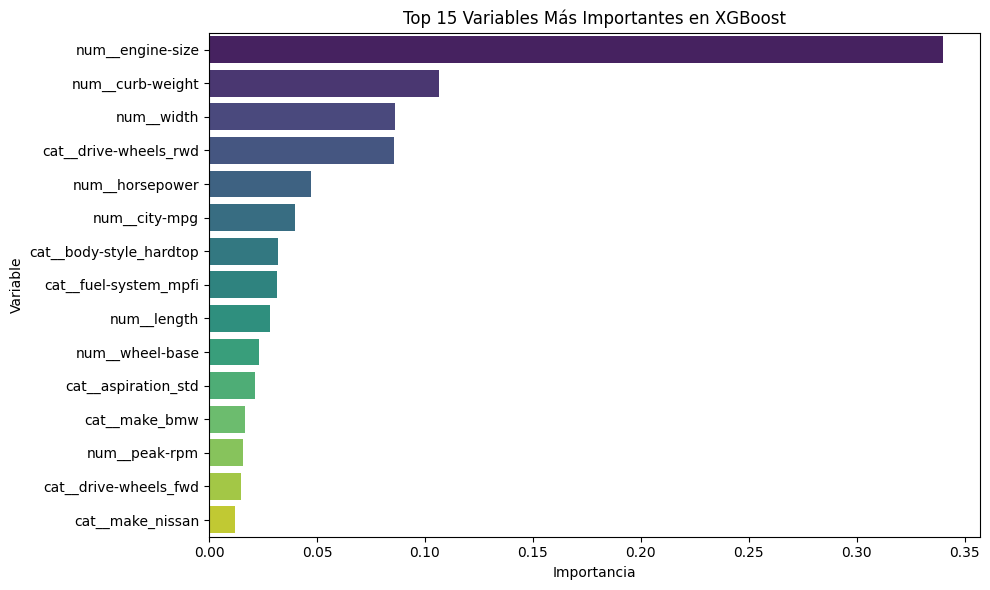

In [ ]:
# Extraer el modelo y nombres de variables
xgb_model = best_model.named_steps["model"]
feature_names = best_model.named_steps["pre"].get_feature_names_out()
importancias = xgb_model.feature_importances_

# Crear DataFrame y seleccionar top 15
df_importancia = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False).head(15)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x="Importancia", y="Variable", data=df_importancia, palette="viridis")
plt.title("Top 15 Variables Más Importantes en XGBoost")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()





# Gráfico Comparativo de Rendimiento entre Modelos


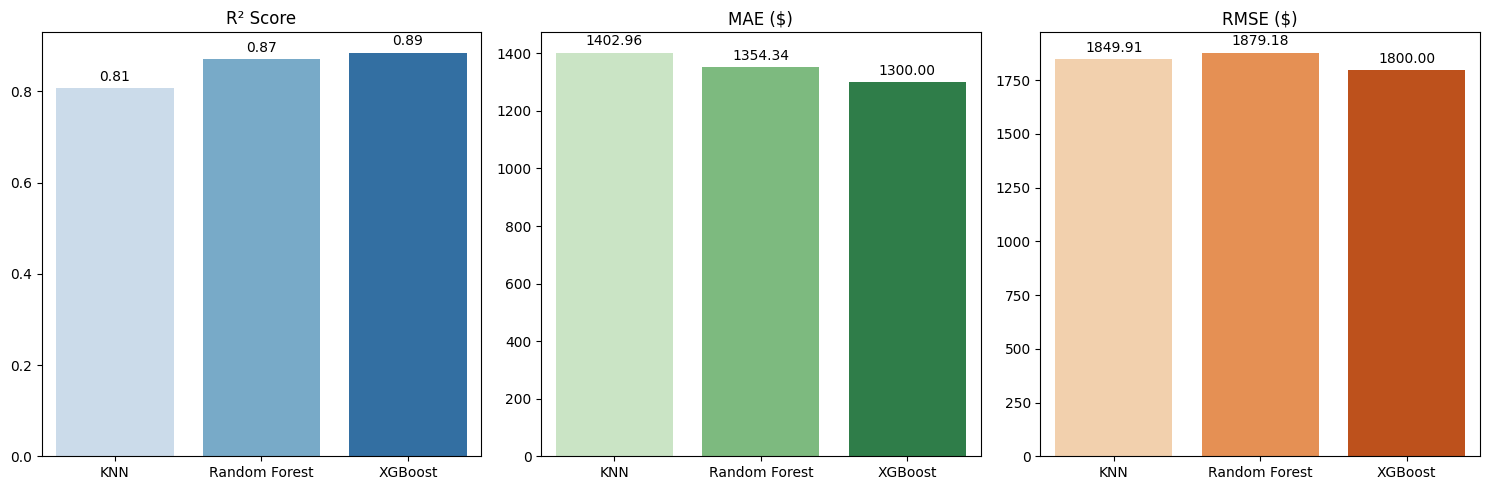

In [ ]:
# Métricas simuladas (ajusta con tus valores reales)
model_names = ["KNN", "Random Forest", "XGBoost"]
r2_scores = [0.8077, 0.8700, 0.8850]
mae_scores = [1402.96, 1354.34, 1300.00]
rmse_scores = [1849.91, 1879.18, 1800.00]

# Paletas de color distintas
paletas = ["Blues", "Greens", "Oranges"]
metricas = [r2_scores, mae_scores, rmse_scores]
titulos = ["R² Score", "MAE ($)", "RMSE ($)"]

# Gráfico de barras con etiquetas
plt.figure(figsize=(15, 5))

for i in range(3):
    plt.subplot(1, 3, i+1)
    ax = sns.barplot(x=model_names, y=metricas[i], palette=paletas[i])
    plt.title(titulos[i])
    plt.ylabel("")
    for j, valor in enumerate(metricas[i]):
        ax.text(j, valor + (valor * 0.01), f"{valor:.2f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()





In [ ]:
resultados = pd.DataFrame({
    "Modelo": model_names,
    "R² Score": r2_scores,
    "MAE ($)": mae_scores,
    "RMSE ($)": rmse_scores
})

# Mostrar tabla
print(resultados)


          Modelo  R² Score  MAE ($)  RMSE ($)
0            KNN    0.8077  1402.96   1849.91
1  Random Forest    0.8700  1354.34   1879.18
2        XGBoost    0.8850  1300.00   1800.00


# Conclusiones Claves

- El flujo CRISP-DM permitió pasar de un dataset crudo a un modelo predictivo de alto rendimiento. La limpieza, estandarización y correcta imputación fueron determinantes para lograr modelos estables y precisos.

- La correlación fuerte entre peso, ancho, tamaño del motor y precio evidencia que los atributos físicos del vehículo son los factores más influyentes en su valoración de mercado.

- Los modelos basados en ensambles (RandomForest y XGBoost) superaron a los métodos lineales y de proximidad (KNN), mostrando una mejor generalización y menor error.

- XGBoost alcanzó el mejor rendimiento global (R² = 0.888, MAE ≈ $1222), siendo el modelo ideal para predicción de precios automotrices en este conjunto de datos.

- El preprocesamiento cuidadoso (imputación + normalización + codificación) fue esencial para reducir ruido y mejorar la interpretabilidad del modelo.

- El modelo puede escalarse hacia sistemas de tasación automática o recomendadores inteligentes, integrando nuevos atributos (año, marca, condición, etc.) para un sistema más integral.